# Analysis

Previously in the EDA, the raw data provided from SMARD has been cleaned up and made usable. In this notebook, the data will be analyzed more in depth.

Analysis will be done based on these questions:

1. How has renewable energy developed compared to conventional energy?
2. What kind of impact did the shut down of nuclear energy have on other energy producers?
3. How did the energy crisis in 2022 influence the sudden rise of energy production through coal?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sys


In [3]:
sys.path.append("../src")

In [4]:
from load_processed_data import load_data

df = load_data("../data/processed/energiedaten_clean.csv")
df

,Datum von,Jahr,Monat,Biomasse [MWh],Wasserkraft [MWh],Wind Offshore [MWh],Wind Onshore [MWh],Photovoltaik [MWh],Sonstige Erneuerbare [MWh],Kernenergie [MWh],...,Wind Offshore [TWh],Wind Onshore [TWh],Photovoltaik [TWh],Sonstige Erneuerbare [TWh],Kernenergie [TWh],Braunkohle [TWh],Steinkohle [TWh],Erdgas [TWh],Pumpspeicher [TWh],Sonstige Konventionelle [TWh]
0,2015-01-01,2015,Januar,3479938.77,1186617.59,264490.14,9404178.83,560194.61,175611.97,8201762.38,...,0.264490,9.404179,0.560195,0.175612,8.201762,11.800183,6.387686,1.405689,0.762023,0.839702
1,2015-02-01,2015,Februar,3153613.46,871004.80,284790.22,5181228.19,1367809.39,154664.97,7498808.73,...,0.284790,5.181228,1.367809,0.154665,7.498809,11.249755,7.886896,1.615353,0.651888,0.797724
2,2015-03-01,2015,März,3437602.13,1030917.99,434443.05,6865747.54,2839770.88,156243.35,7308641.32,...,0.434443,6.865748,2.839771,0.156243,7.308641,12.177183,7.320064,1.359909,0.718934,0.817339
3,2015-04-01,2015,April,3269723.30,1248928.32,379940.40,4837677.66,4380466.76,151245.19,6858356.45,...,0.379940,4.837678,4.380467,0.151245,6.858356,10.200743,5.994325,0.850197,0.676780,0.770987
4,2015-05-01,2015,Mai,3361025.36,1560655.41,566551.40,4848138.13,4366740.00,136081.97,6930784.48,...,0.566551,4.848138,4.366740,0.136082,6.930784,8.935798,4.295092,0.866135,0.747063,0.714053
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127,2025-08-01,2025,August,2852499.35,1463011.45,1699077.95,5459159.51,9672278.48,73973.16,0.00,...,1.699078,5.459160,9.672278,0.073973,0.000000,4.518748,1.301445,3.015975,0.843045,1.075940
128,2025-09-01,2025,September,2794210.42,1208876.63,2410541.28,9721142.41,6435895.39,72157.99,0.00,...,2.410541,9.721142,6.435895,0.072158,0.000000,4.925689,1.397569,3.790774,0.733651,1.014139
129,2025-10-01,2025,Oktober,3034056.45,1116769.65,2901834.16,13695534.40,3642622.45,79788.30,0.00,...,2.901834,13.695534,3.642622,0.079788,0.000000,5.648721,2.166157,5.275414,0.756737,1.394099
130,2025-11-01,2025,November,3069622.61,1084135.10,2716300.26,9952192.85,2210900.10,81528.93,0.00,...,2.716300,9.952193,2.210900,0.081529,0.000000,6.595504,3.165925,7.519788,0.673562,1.350663


A small script has been made to keep the name of the months in chronological order instead of alphabetical.

In [5]:
energy_columns = [
        "Biomasse [MWh]", "Wasserkraft [MWh]", "Wind Offshore [MWh]", "Wind Onshore [MWh]", "Photovoltaik [MWh]",
        "Sonstige Erneuerbare [MWh]", "Kernenergie [MWh]", "Braunkohle [MWh]", "Steinkohle [MWh]", "Erdgas [MWh]",
        "Pumpspeicher [MWh]", "Sonstige Konventionelle [MWh]"
]

df_yearly = df.groupby("Jahr")[energy_columns].sum().reset_index()
df_yearly

,Jahr,Biomasse [MWh],Wasserkraft [MWh],Wind Offshore [MWh],Wind Onshore [MWh],Photovoltaik [MWh],Sonstige Erneuerbare [MWh],Kernenergie [MWh],Braunkohle [MWh],Steinkohle [MWh],Erdgas [MWh],Pumpspeicher [MWh],Sonstige Konventionelle [MWh]
0,2015,39751084.46,14094166.35,8162735.76,7.116874e+07,34734680.78,1813303.53,84363484.91,1.337977e+08,81138651.55,15225876.55,8200438.23,10425309.06
1,2016,41055826.95,18014518.07,12093095.10,6.630889e+07,34998505.32,1835926.08,80242428.94,1.303756e+08,80889893.10,22888748.59,8100141.24,13741868.88
2,2017,40569479.16,15598671.37,17414165.36,8.596758e+07,35779399.79,1724131.32,72213907.40,1.292866e+08,66005458.63,25580321.39,8619064.83,15780912.87
3,2018,39526471.19,15541981.82,19068370.50,8.932284e+07,41196076.09,1461998.21,71841601.48,1.283299e+08,71545219.59,42878165.39,8804806.38,15669558.49
4,2019,39478585.50,16471220.75,24382827.00,9.972831e+07,41706959.00,1557516.00,71042164.25,1.027287e+08,47815284.50,54619705.25,8610896.75,13225241.75
5,2020,39966301.25,15945659.50,26883159.25,1.030832e+08,45784303.00,1602116.50,60923886.25,8.337401e+07,34871983.75,67621507.50,10817558.75,12753899.75
6,2021,38235128.00,14888434.25,24010320.50,8.956511e+07,46230946.00,1431867.00,65405986.50,9.820223e+07,51841756.25,60120638.75,8264355.00,13098558.75
7,2022,37738237.75,12804450.00,24747841.00,1.009853e+08,55727425.00,1290692.75,32824469.50,1.035256e+08,62889869.75,45778264.00,10153823.50,11515547.00
8,2023,37295318.00,15019800.25,23519929.50,1.190071e+08,55544029.25,1205180.75,6740739.25,7.784406e+07,39750012.75,51089841.00,10175978.25,16358340.75
9,2024,36197008.25,17551916.00,25667479.75,1.125604e+08,63148433.00,1058739.25,0.00,7.098635e+07,27336318.75,56916481.25,10390692.75,15840636.50


## 1. Development Renewable vs. Conventional

The environmental crisis is an important topic all over the world. That's why the research, development and usage of renewable energy has a high priority. But how has it developed in Germany over the years? Even more so, because at the same time, conventional production needs to be lowered down at the same time.

In [6]:
renewable_columns = [
    "Biomasse [MWh]", "Wasserkraft [MWh]", "Wind Offshore [MWh]",
    "Wind Onshore [MWh]", "Photovoltaik [MWh]", "Sonstige Erneuerbare [MWh]"
]

conventional_columns = [
    "Kernenergie [MWh]", "Braunkohle [MWh]", "Steinkohle [MWh]",
    "Erdgas [MWh]", "Pumpspeicher [MWh]", "Sonstige Konventionelle [MWh]"
]

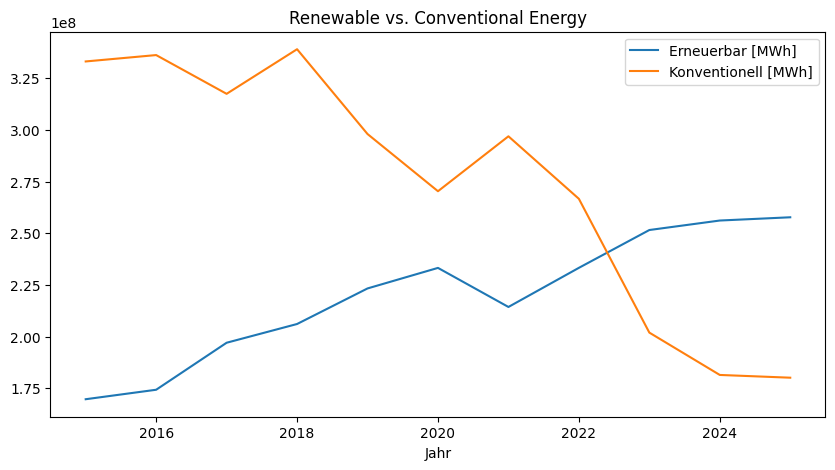

In [7]:
df_yearly["Erneuerbar [MWh]"] = df_yearly[renewable_columns].sum(axis=1)
df_yearly["Konventionell [MWh]"] = df_yearly[conventional_columns].sum(axis=1)

df_yearly.set_index("Jahr")[["Erneuerbar [MWh]", "Konventionell [MWh]"]].plot(figsize=(10, 5), title="Renewable vs. Conventional Energy")
plt.show()

As a first insight, the production of conventional energy is far higher in the beginning years compared to renewable energy. After 2018, the growth of renewable energy has increased while conventional energy has a sharp descent. This trend gets reversed between 2020 - 2021 as conventional is on the rise again while renewable falls down slightly.

In [41]:
row_2021_conv = df_yearly.loc[df_yearly["Jahr"] == 2021, conventional_columns].squeeze()
row_2020_conv = df_yearly.loc[df_yearly["Jahr"] == 2020, conventional_columns].squeeze()

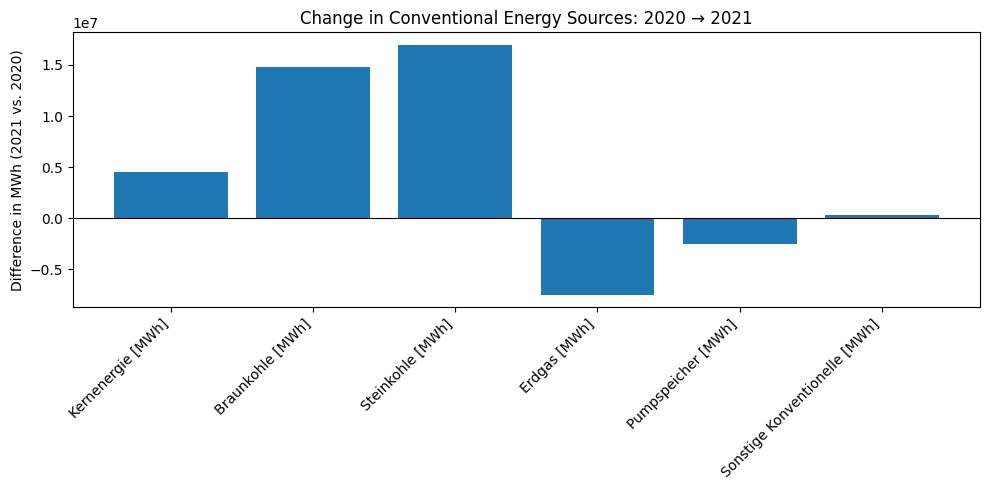

In [42]:
diff_conv = row_2021_conv - row_2020_conv

plt.figure(figsize=(10, 5))
plt.bar(diff_conv.index, diff_conv.values)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Difference in MWh (2021 vs. 2020)")
plt.title("Change in Conventional Energy Sources: 2020 → 2021")
plt.axhline(0, color="black", linewidth=0.8)  # Nulllinie zur Orientierung
plt.tight_layout()
plt.show()

In [43]:
row_2021_ren = df_yearly.loc[df_yearly["Jahr"] == 2021, renewable_columns].squeeze()
row_2020_ren = df_yearly.loc[df_yearly["Jahr"] == 2020, renewable_columns].squeeze()

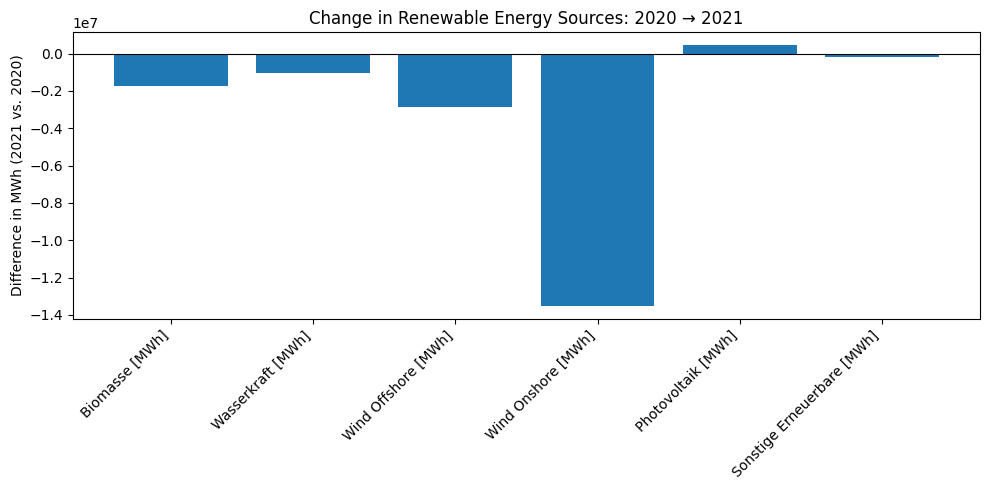

In [45]:
diff_ren = row_2021_ren - row_2020_ren

plt.figure(figsize=(10, 5))
plt.bar(diff_ren.index, diff_ren.values)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Difference in MWh (2021 vs. 2020)")
plt.title("Change in Renewable Energy Sources: 2020 → 2021")
plt.axhline(0, color="black", linewidth=0.8)  # Nulllinie zur Orientierung
plt.tight_layout()
plt.show()

If we compare the differences of conventional and renewable energy between 2020 and 2021, wind energy onshore is drastically lower in 2021 than 2020. Compared to 2020, which had lots of strong winds in Germany, the winds in 2021 were a lot weaker. This shows that in these years Germanies infrastructure was still strongly dependant on the weather. Since the demand on energy was rising after the start of the corona pandemic in 2020 and the low energy production through wind, the energy production through coal was increased to compensate it.

In [15]:
df_2022 = df[df["Jahr"] == 2022].copy()

df_2022["Renewable"] = df_2022[renewable_columns].sum(axis=1)
df_2022["Conventional"] = df_2022[conventional_columns].sum(axis=1)

df_2022_monthly = df_2022[["Monat", "Renewable", "Conventional"]]

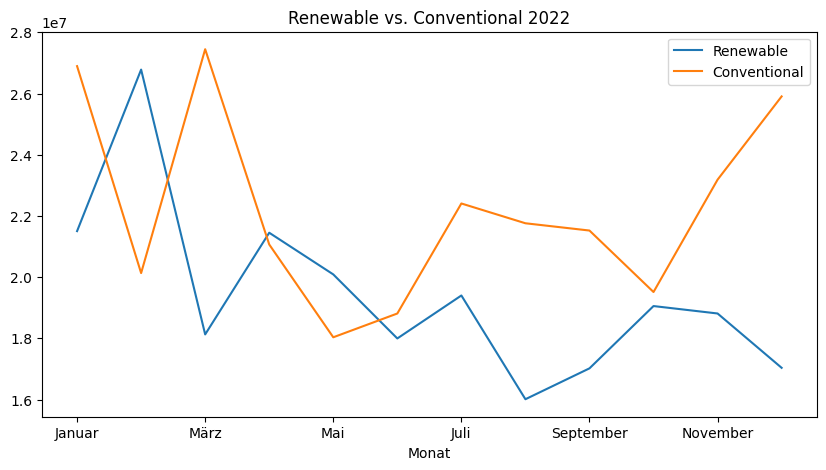

In [17]:
df_2022_monthly.set_index("Monat")[["Renewable", "Conventional"]].plot(figsize=(10, 5), title="Renewable vs. Conventional 2022")
plt.show()

According to this chart, renewable and conventional energy fluctuate in the first half of the year. But the more important insight is that renewable energy doesn't overtake conventional energy in 2022. On the contrary: From June onwards conventional energy is consistently higher than renewable. This disproves the first assumption that renewable energy overtakes conventional energy in the year 2022.

In [12]:
df_2023 = df[df["Jahr"] == 2023].copy()

df_2023["Renewable"] = df_2023[renewable_columns].sum(axis=1)
df_2023["Conventional"] = df_2023[conventional_columns].sum(axis=1)

df_2023_monthly = df_2023[["Monat", "Renewable", "Conventional"]]

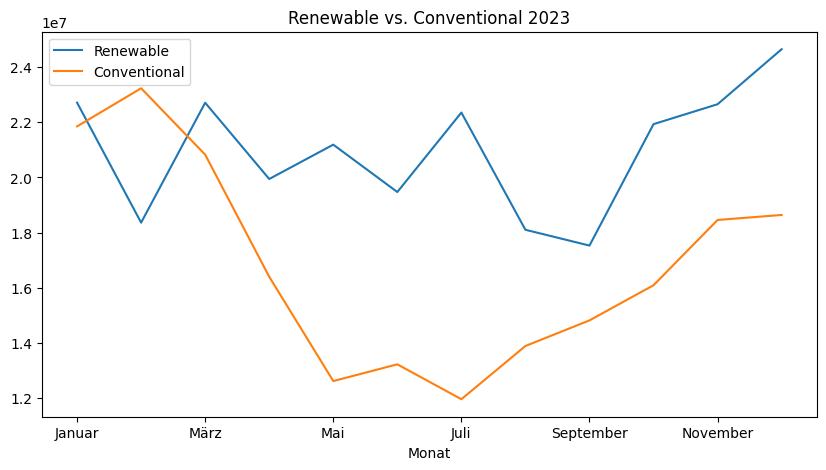

In [14]:
df_2023_monthly.set_index("Monat")[["Renewable", "Conventional"]].plot(figsize=(10, 5), title="Renewable vs. Conventional 2023")
plt.show()

In 2023, the transition is clearer: From March onward, renewable energy remains higher than conventional energy. You can see a huge descent from March to May in the conventional sector. In April 2023, the final nuclear reactors were shut down. The shut downs were the final straw to break for Germany to make production of energy from renewable sources consistently higher than conventional. The impact of the nuclear phase-out will be looked at more in depth in the second chapter.

In conclusion: The overall development in Germany is weighted on renewable energy. Aside from the dropdown in 2021, renewable energy was steadily rising unlike conventional energy which was slowly getting reduced. The final break point was in 2023 when the nuclear shut down was official and renewable energy became the bigger energy source.

## 2. Impact